# Sklearn + PyTorch 
## 从数据准备到最小神经网络训练

**适用对象**：会基本 Python 语法，刚开始学习机器学习和 PyTorch 的新手。    
**运行方式**：按照 Notebook 顺序，从上到下逐个运行 Cell。  
**数据来源**：使用 sklearn 在线生成二维分类数据，不需要下载外部数据。

---

## 核心学习目标

完成本 Notebook 后，应能：

1. 创建 Tensor，并根据计算机环境选择 CPU 或 CUDA。
2. 使用 `requires_grad=True` 和 `backward()` 计算自动微分梯度。
3. 理解梯度为什么会累积，以及为什么训练时需要 `zero_grad()`。
4. 使用 sklearn 生成、划分和标准化分类数据。
5. 使用自定义 `Dataset` 保存样本和标签。
6. 使用 `DataLoader` 按批次读取数据。
7. 使用 `nn.Module` 定义一个最小神经网络。
8. 完成“前向传播 → 计算损失 → 反向传播 → 更新参数”的训练循环。
9. 使用 Accuracy、分类报告和混淆矩阵评估模型。

> 今天的重点不是复杂网络，而是完整跑通一次规范、可解释的训练流程。

In [1]:
import sys
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Python:", sys.version.split()[0])
print("scikit-learn:", sklearn.__version__)
print("PyTorch:", torch.__version__)

Python: 3.12.4
scikit-learn: 1.9.0
PyTorch: 2.13.0+cpu


# 1.Tensor与 CPU/CUDA设备
## 1.1 什么是 Tensor

Tensor 可以理解为 PyTorch 中的多维数组：

- 标量：0 维 Tensor
- 向量：1 维 Tensor
- 矩阵：2 维 Tensor
- 图像批次等数据：3 维及以上 Tensor

训练神经网络时，输入、标签、模型参数和梯度通常都是 Tensor。

In [2]:
scalar = torch.tensor(3.14)
vector = torch.tensor([1.0, 2.0, 3.0])
matrix = torch.tensor([
    [1.0, 2.0],
    [3.0, 4.0]
])
random_tensor = torch.randn(3, 4)
zeros = torch.zeros(2, 3)
ones = torch.ones(2, 3)

print("标量：", scalar, "shape =", scalar.shape)
print("向量：", vector, "shape =", vector.shape)
print("矩阵：\n", matrix, "\nshape =", matrix.shape)
print("随机 Tensor shape：", random_tensor.shape)
print("全零 Tensor：\n", zeros)
print("全一 Tensor：\n", ones)

标量： tensor(3.1400) shape = torch.Size([])
向量： tensor([1., 2., 3.]) shape = torch.Size([3])
矩阵：
 tensor([[1., 2.],
        [3., 4.]]) 
shape = torch.Size([2, 2])
随机 Tensor shape： torch.Size([3, 4])
全零 Tensor：
 tensor([[0., 0., 0.],
        [0., 0., 0.]])
全一 Tensor：
 tensor([[1., 1., 1.],
        [1., 1., 1.]])


## 1.2 数据类型

常见类型：

- 特征通常使用 `torch.float32`
- 分类标签通常使用 `torch.long`
- `CrossEntropyLoss` 要求类别标签是整数类型 `long`

In [3]:
features_example = torch.tensor(
    [[1, 2], [3, 4]],
    dtype=torch.float32
)

labels_example = torch.tensor(
    [0, 1],
    dtype=torch.long
)

print("特征 dtype：", features_example.dtype)
print("标签 dtype：", labels_example.dtype)

特征 dtype： torch.float32
标签 dtype： torch.int64


## 1.3 自动选择 CPU 或 CUDA

CUDA 是 NVIDIA GPU 的并行计算平台。

下面的代码会：

- 有可用 CUDA 时选择 GPU；
- 否则自动选择 CPU。

无论使用哪种设备，Tensor 和模型必须位于同一设备。

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("当前设备：", device)
print("CUDA 是否可用：", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU 名称：", torch.cuda.get_device_name(0))

当前设备： cpu
CUDA 是否可用： False


In [5]:
tensor_on_device = features_example.to(device)

print("移动前设备：", features_example.device)
print("移动后设备：", tensor_on_device.device)

移动前设备： cpu
移动后设备： cpu


# 2.用backward（）计算自动微分梯度
## 2.1 标量函数示例

定义：

\[
z=x^2+2xy+y^3
\]

理论梯度：

\[
\frac{\partial z}{\partial x}=2x+2y
\]

\[
\frac{\partial z}{\partial y}=2x+3y^2
\]

当 \(x=2,y=3\) 时：

- \(\frac{\partial z}{\partial x}=10\)
- \(\frac{\partial z}{\partial y}=31\)

In [6]:
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

z = x**2 + 2*x*y + y**3

print("backward 前：")
print("x.grad =", x.grad)
print("y.grad =", y.grad)

z.backward()

print("\nbackward 后：")
print("z =", z.item())
print("dz/dx =", x.grad.item())
print("dz/dy =", y.grad.item())

assert x.grad.item() == 10.0
assert y.grad.item() == 31.0

backward 前：
x.grad = None
y.grad = None

backward 后：
z = 43.0
dz/dx = 10.0
dz/dy = 31.0


## 2.2 这段代码发生了什么

1. `requires_grad=True`：要求 PyTorch 记录与该 Tensor 有关的运算。
2. 计算 `z`：PyTorch 同时构建计算图。
3. `z.backward()`：从结果向前追溯，使用链式法则计算梯度。
4. 梯度保存在叶子 Tensor 的 `.grad` 属性中。
## 2.3 梯度会累积

In [7]:
a = torch.tensor(2.0, requires_grad=True)

loss_1 = a**2
loss_1.backward()
print("第一次 backward 后 a.grad =", a.grad.item())

loss_2 = 3*a
loss_2.backward()
print("未清零，再次 backward 后 a.grad =", a.grad.item())

a.grad.zero_()

loss_3 = 3*a
loss_3.backward()
print("清零后，再次 backward 后 a.grad =", a.grad.item())

第一次 backward 后 a.grad = 4.0
未清零，再次 backward 后 a.grad = 7.0
清零后，再次 backward 后 a.grad = 3.0


第一次梯度是 4，第二次梯度是 3。

未清零时，结果为：

\[
4+3=7
\]

因此训练模型时，每个 batch 开始前必须执行：

```python
optimizer.zero_grad()
```
## 2.4 不记录梯度的推理

In [9]:
with torch.no_grad():
    result = x + y
    print("推理结果：", result.item())
    print("是否记录梯度：", result.requires_grad)

推理结果： 5.0
是否记录梯度： False


`torch.no_grad()` 常用于验证和测试：

- 不构建计算图；
- 节省内存；

# 3. 用 sklearn 准备分类数据
为了让实验易于理解，使用 `make_moons` 生成二维二分类数据。

每个样本有两个特征，标签是 0 或 1。数据形状可直接画在平面上。

In [10]:
from sklearn.datasets import make_moons

X, y_np = make_moons(
    n_samples=800,
    noise=0.20,
    random_state=SEED
)

print("X shape：", X.shape)
print("y shape：", y_np.shape)
print("前 5 个样本：\n", X[:5])
print("前 5 个标签：", y_np[:5])

X shape： (800, 2)
y shape： (800,)
前 5 个样本：
 [[ 1.4916376  -0.12415845]
 [ 1.4007517  -0.52063633]
 [ 0.85806768  0.26889893]
 [ 0.38927014 -0.60560098]
 [ 1.26093213  0.50363945]]
前 5 个标签： [1 1 0 1 0]


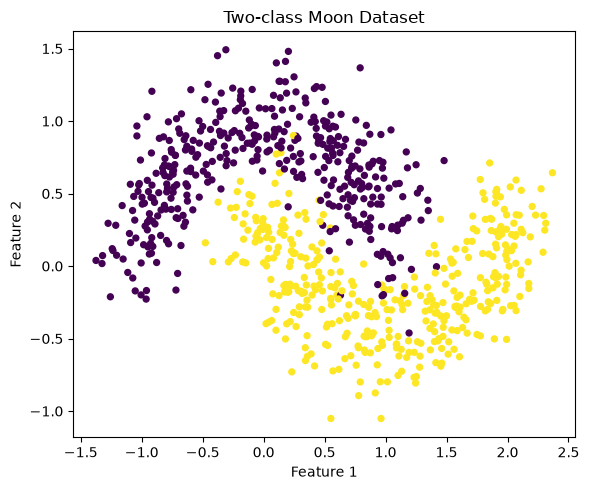

In [11]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y_np, s=18)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Two-class Moon Dataset")
plt.tight_layout()
plt.show()

## 3.1 划分训练集和测试集

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_np,
    test_size=0.20,
    random_state=SEED,
    stratify=y_np
)

print("训练集：", X_train.shape, y_train.shape)
print("测试集：", X_test.shape, y_test.shape)
print("训练集正类比例：", round(y_train.mean(), 3))
print("测试集正类比例：", round(y_test.mean(), 3))

训练集： (640, 2) (640,)
测试集： (160, 2) (160,)
训练集正类比例： 0.5
测试集正类比例： 0.5


- 训练集用于学习模型参数。
- 测试集用于最后评估。
- `stratify=y_np` 保持两个集合的类别比例相近。

## 3.2 标准化特征

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("训练集标准化后均值：", X_train_scaled.mean(axis=0).round(4))
print("训练集标准化后标准差：", X_train_scaled.std(axis=0).round(4))

训练集标准化后均值： [ 0. -0.]
训练集标准化后标准差： [1. 1.]


必须区分：

```python
scaler.fit_transform(X_train)
scaler.transform(X_test)
```

标准化器只能在训练集上拟合。测试集不能参与均值和标准差的计算，否则会产生数据泄露。

# 4. 用 Dataset 和 DataLoader 组织数据

## 4.1 自定义 Dataset

一个最小 Dataset 通常需要实现：

- `__init__`：保存数据
- `__len__`：返回样本数量
- `__getitem__`：根据索引返回一个样本及其标签

In [16]:
class MoonDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]
        

In [17]:
train_dataset = MoonDataset(X_train_scaled, y_train)
test_dataset = MoonDataset(X_test_scaled, y_test)

print("训练样本数：", len(train_dataset))
print("测试样本数：", len(test_dataset))

sample_x, sample_y = train_dataset[0]

print("一个样本的特征：", sample_x)
print("一个样本的标签：", sample_y)
print("特征 dtype：", sample_x.dtype)
print("标签 dtype：", sample_y.dtype)

训练样本数： 640
测试样本数： 160
一个样本的特征： tensor([-0.2863,  0.9662])
一个样本的标签： tensor(0)
特征 dtype： torch.float32
标签 dtype： torch.int64


## 4.2 使用 DataLoader 按批次加载

In [18]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

batch_x, batch_y = next(iter(train_loader))

print("一个 batch 的特征形状：", batch_x.shape)
print("一个 batch 的标签形状：", batch_y.shape)
print("前 5 个标签：", batch_y[:5])

一个 batch 的特征形状： torch.Size([32, 2])
一个 batch 的标签形状： torch.Size([32])
前 5 个标签： tensor([0, 0, 1, 0, 1])


### 参数解释

- `batch_size=32`：每次取 32 个样本。
- `shuffle=True`：训练时打乱样本顺序。
- 测试时通常使用 `shuffle=False`。

# 5. 用 nn.Module 定义最小神经网络
模型结构：

1. 输入层：2 个特征
2. 隐藏层：16 个神经元
3. ReLU 激活函数
4. 输出层：2 个类别

输出是两个 logits，不需要手动添加 Softmax，因为 `CrossEntropyLoss` 内部已经处理。

In [19]:
class SimpleClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, batch_x):
        return self.network(batch_x)


model = SimpleClassifier().to(device)

print(model)
print("模型所在设备：", next(model.parameters()).device)

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("可训练参数量：", parameter_count)

SimpleClassifier(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=2, bias=True)
  )
)
模型所在设备： cpu
可训练参数量： 82


## 5.1 一次前向传播

输入形状是 `(batch_size, 2)`，输出形状应为 `(batch_size, 2)`。

In [21]:
batch_x = batch_x.to(device)
batch_y = batch_y.to(device)

logits = model(batch_x)

print("输入形状：", batch_x.shape)
print("输出形状：", logits.shape)
print("前 3 个 logits：\n", logits[:3])

输入形状： torch.Size([32, 2])
输出形状： torch.Size([32, 2])
前 3 个 logits：
 tensor([[-0.5008, -0.2020],
        [-0.7213, -0.4765],
        [ 0.0848, -0.2398]], grad_fn=<SliceBackward0>)


# 6. 完成最小训练实验
## 6.1 训练需要的三个对象

- 模型：`model`
- 损失函数：`CrossEntropyLoss`
- 优化器：`Adam`

每个 batch 的五个固定步骤：

1. `optimizer.zero_grad()`：清空旧梯度
2. `logits = model(batch_x)`：前向传播
3. `loss = criterion(logits, batch_y)`：计算损失
4. `loss.backward()`：反向传播
5. `optimizer.step()`：更新参数

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.02
)

print("损失函数：", criterion)
print("优化器：", optimizer.__class__.__name__)

损失函数： CrossEntropyLoss()
优化器： Adam


## 6.2 训练一个 epoch 的函数

In [23]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        logits = model(batch_x)
        loss = criterion(logits, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_y.size(0)

        predictions = logits.argmax(dim=1)
        correct += (predictions == batch_y).sum().item()
        total += batch_y.size(0)

    average_loss = total_loss / total
    accuracy = correct / total

    return average_loss, accuracy

## 6.3 测试函数

In [24]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []

    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        logits = model(batch_x)
        loss = criterion(logits, batch_y)

        predictions = logits.argmax(dim=1)

        total_loss += loss.item() * batch_y.size(0)
        correct += (predictions == batch_y).sum().item()
        total += batch_y.size(0)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

    average_loss = total_loss / total
    accuracy = correct / total

    return average_loss, accuracy, np.array(all_predictions), np.array(all_labels)

## 6.4 运行完整训练

In [25]:
EPOCHS = 60

train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    test_loss, test_accuracy, _, _ = evaluate(
        model,
        test_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"Train Loss={train_loss:.4f}, "
            f"Train Acc={train_accuracy:.3f} | "
            f"Test Loss={test_loss:.4f}, "
            f"Test Acc={test_accuracy:.3f}"
        )

Epoch 01/60 | Train Loss=0.4327, Train Acc=0.816 | Test Loss=0.2503, Test Acc=0.894
Epoch 10/60 | Train Loss=0.1165, Train Acc=0.961 | Test Loss=0.1058, Test Acc=0.988
Epoch 20/60 | Train Loss=0.0887, Train Acc=0.967 | Test Loss=0.0836, Test Acc=0.963
Epoch 30/60 | Train Loss=0.0831, Train Acc=0.972 | Test Loss=0.0789, Test Acc=0.981
Epoch 40/60 | Train Loss=0.0822, Train Acc=0.969 | Test Loss=0.0791, Test Acc=0.975
Epoch 50/60 | Train Loss=0.0792, Train Acc=0.966 | Test Loss=0.0803, Test Acc=0.969
Epoch 60/60 | Train Loss=0.0719, Train Acc=0.972 | Test Loss=0.0854, Test Acc=0.963


## 6.5 绘制训练曲线

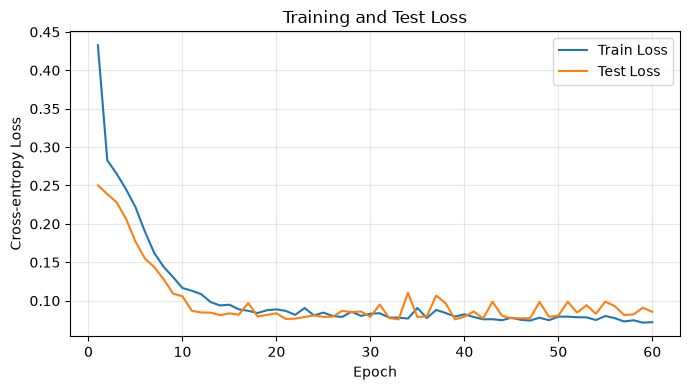

In [26]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss")
plt.plot(range(1, EPOCHS + 1), test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

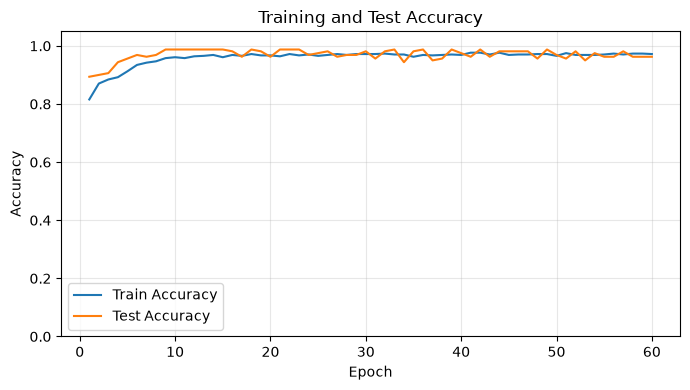

In [27]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS + 1), train_accuracies, label="Train Accuracy")
plt.plot(range(1, EPOCHS + 1), test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

观察训练曲线：

- Loss 总体下降，说明模型逐渐减少预测错误。
- Accuracy 总体上升，说明分类正确的样本增加。
- 若训练集持续变好而测试集明显变差，可能发生过拟合。
# 7. 用 sklearn 评估 PyTorch 模型

In [28]:
final_test_loss, final_test_accuracy, test_predictions, test_labels = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print("最终测试 Loss：", round(final_test_loss, 4))
print("最终测试 Accuracy：", round(final_test_accuracy, 4))

assert final_test_accuracy > 0.85, "准确率偏低，请检查是否按顺序运行了全部训练 Cell"

最终测试 Loss： 0.0854
最终测试 Accuracy： 0.9625


In [29]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=["Class 0", "Class 1"]
    )
)

              precision    recall  f1-score   support

     Class 0       0.95      0.97      0.96        80
     Class 1       0.97      0.95      0.96        80

    accuracy                           0.96       160
   macro avg       0.96      0.96      0.96       160
weighted avg       0.96      0.96      0.96       160



分类报告中的核心指标：

- **Precision**：预测为某类的样本中，有多少是真的。
- **Recall**：真实属于某类的样本中，有多少被找出来。
- **F1-score**：Precision 和 Recall 的综合结果。

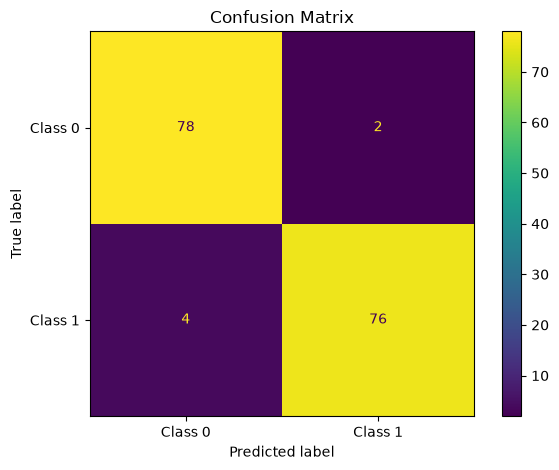

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    test_labels,
    test_predictions,
    display_labels=["Class 0", "Class 1"]
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

混淆矩阵：

- 对角线表示预测正确；
- 非对角线表示预测错误。

请记录两个类别分别被错分了多少次。
# 8. 查看神经网络参数的梯度
下面单独取一个 batch，只执行到 `backward()`，观察模型参数的梯度。

梯度表示：如果参数发生微小变化，Loss 会朝哪个方向、以多大速度变化。

In [31]:
model.zero_grad()

one_batch_x, one_batch_y = next(iter(train_loader))
one_batch_x = one_batch_x.to(device)
one_batch_y = one_batch_y.to(device)

one_batch_logits = model(one_batch_x)
one_batch_loss = criterion(one_batch_logits, one_batch_y)

one_batch_loss.backward()

for name, parameter in model.named_parameters():
    print(
        f"{name:20s} | "
        f"shape={tuple(parameter.shape)} | "
        f"grad_norm={parameter.grad.norm().item():.6f}"
    )

network.0.weight     | shape=(16, 2) | grad_norm=0.055418
network.0.bias       | shape=(16,) | grad_norm=0.037441
network.2.weight     | shape=(2, 16) | grad_norm=0.034246
network.2.bias       | shape=(2,) | grad_norm=0.008212


如果某个可训练参数的 `grad` 长期为 `None`，可能说明：

- 它没有参与前向计算；
- 计算图被错误切断；
- 使用了不合适的 `detach()`；
- 在错误位置使用了 `torch.no_grad()`。

# 9. 新手独立练习
## 练习 1：Tensor 与设备

创建一个形状为 `(4, 3)` 的随机 Tensor：

1. 数据类型为 `float32`；
2. 移动到 `device`；
3. 输出 shape、dtype 和 device。

In [33]:
# TODO：先独立完成，再查看下面的参考写法

exercise_tensor = torch.randn(4, 3, dtype=torch.float32).to(device)

print("shape：", exercise_tensor.shape)
print("dtype：", exercise_tensor.dtype)
print("device：", exercise_tensor.device)

shape： torch.Size([4, 3])
dtype： torch.float32
device： cpu


## 练习 2：autograd

定义：

\[
f(x)=x^3+2x^2-5x+1
\]

令 \(x=2\)，使用 `backward()` 求梯度，并与手算结果比较。

理论导数：

\[
f'(x)=3x^2+4x-5
\]

In [34]:
x_exercise = torch.tensor(2.0, requires_grad=True)

f = x_exercise**3 + 2*x_exercise**2 - 5*x_exercise + 1
f.backward()

autograd_gradient = x_exercise.grad.item()
manual_gradient = 3*(2**2) + 4*2 - 5

print("autograd 梯度：", autograd_gradient)
print("手算梯度：", manual_gradient)

assert autograd_gradient == manual_gradient

autograd 梯度： 15.0
手算梯度： 15


## 练习 3：修改训练设置

分别尝试：

- `batch_size=16`
- `batch_size=64`
- 学习率 `lr=0.005`
- 隐藏层神经元从 16 改为 32

记录：

| 设置 | 最终测试 Accuracy | 训练曲线现象 |
|---|---:|---|
| 原设置 |  |  |
| 修改 1 |  |  |
| 修改 2 |  |  |

注意：每次修改模型结构或学习率后，应重新创建模型和优化器，再从头训练。